Working directory: C:\Users\dell\ComputerVision\Lab 5\360-Panorama
Using image folder: 360_images
Files in folder: ['1.jpeg', '2.jpeg', '3.jpeg', '4.jpeg', '5.jpeg', '6.jpeg']
Loaded: 1.jpeg | shape: (800, 298, 3)
Loaded: 2.jpeg | shape: (800, 289, 3)
Loaded: 3.jpeg | shape: (800, 285, 3)
Loaded: 4.jpeg | shape: (800, 361, 3)
Loaded: 5.jpeg | shape: (800, 280, 3)
Loaded: 6.jpeg | shape: (800, 447, 3)

Total loaded images: 6


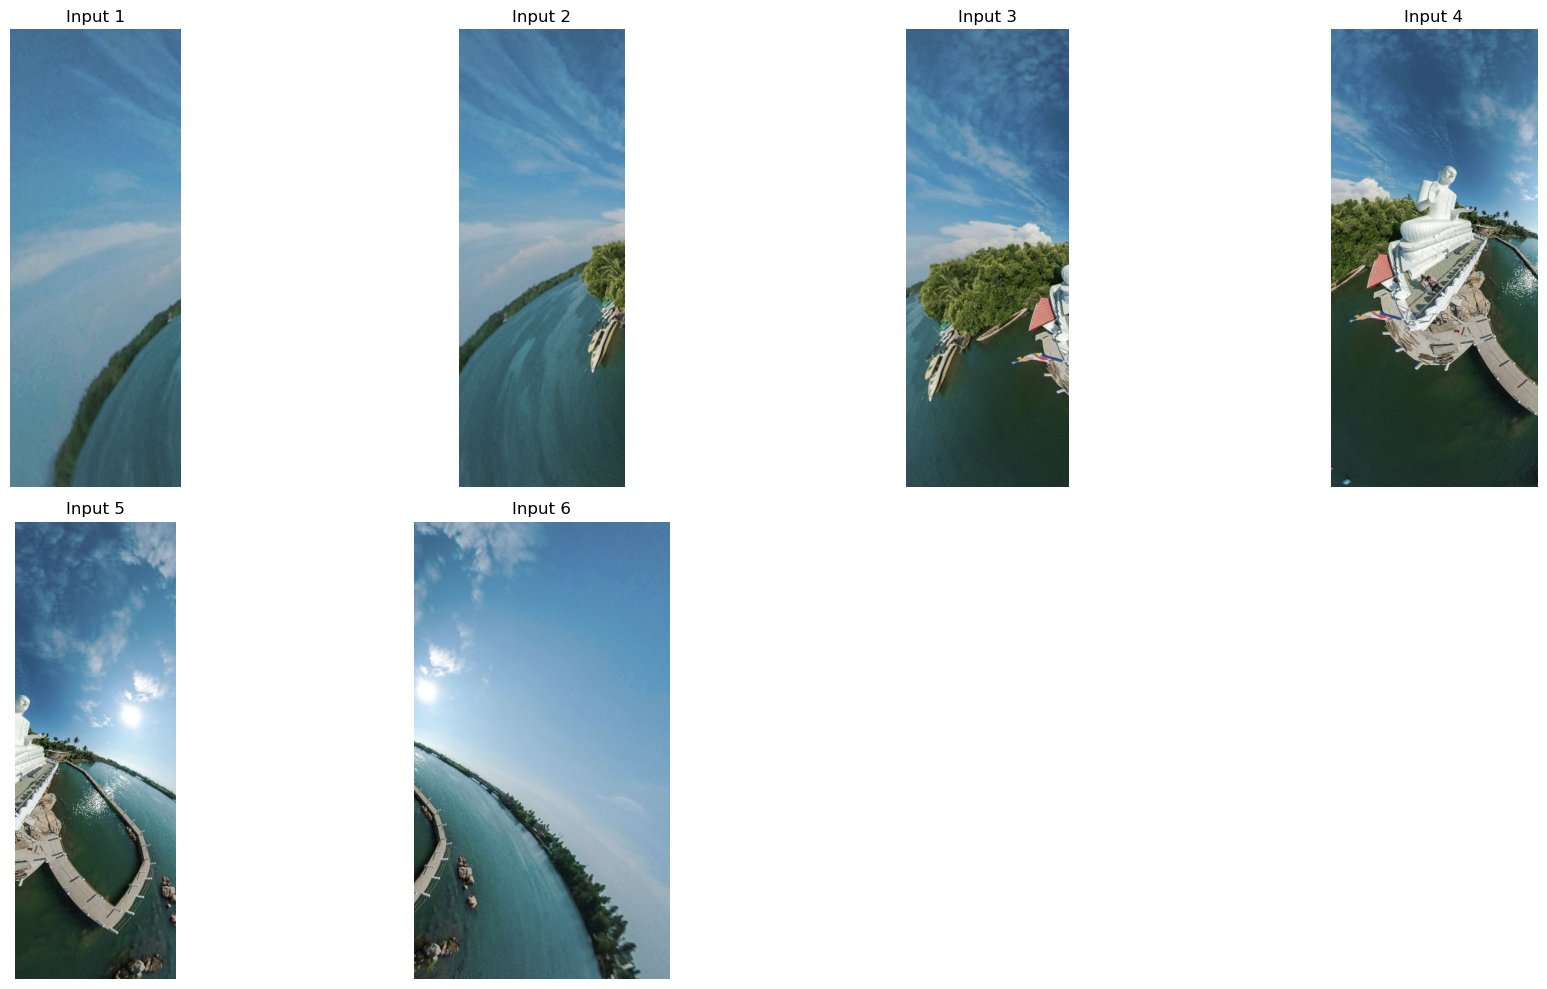


Checking feature matching between first two images...
Good matches: 1


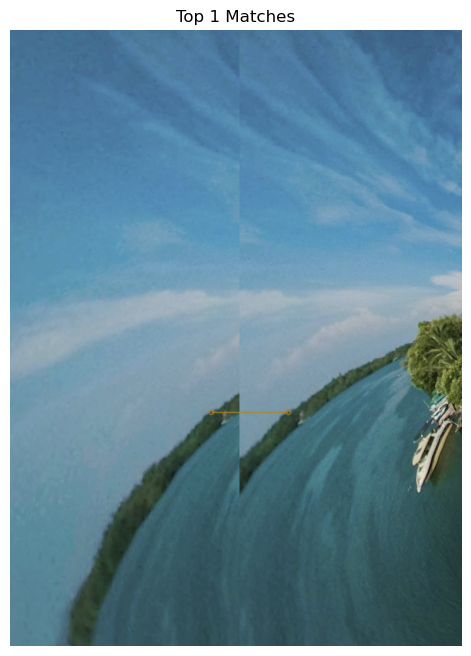


Running OpenCV Stitcher in PANORAMA mode...
PANORAMA mode failed. Status code: 3

Running OpenCV Stitcher in SCANS mode...


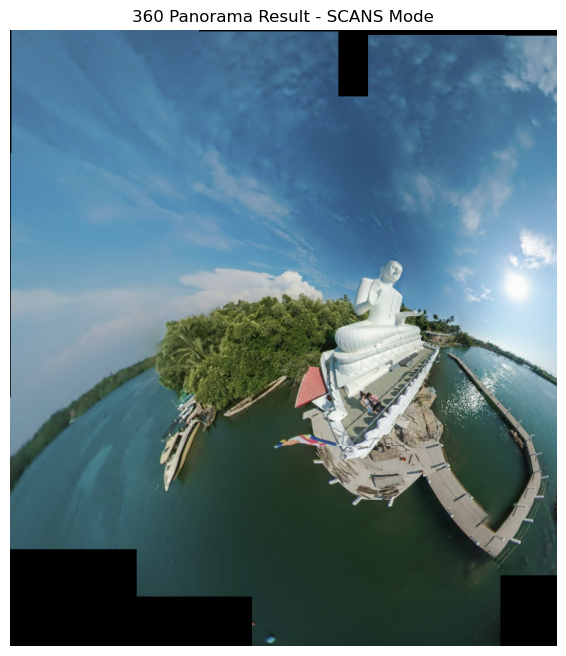

Saved: output_360_panorama\scans_mode_result.jpg


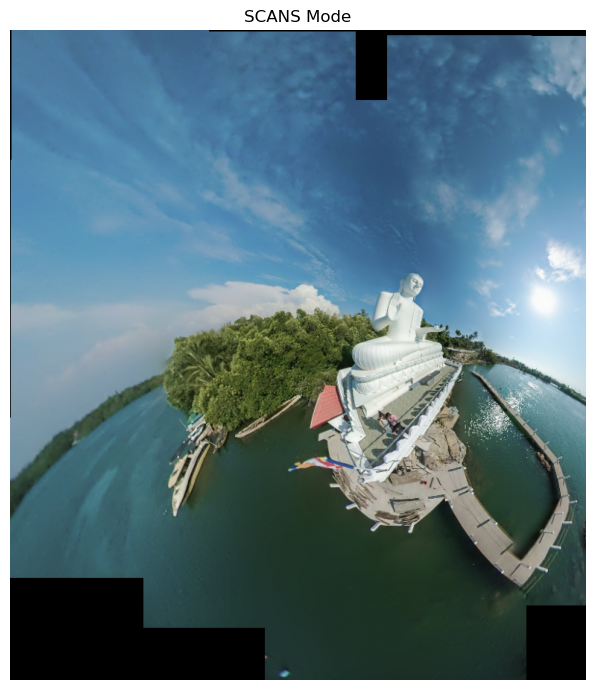


Best final output selected: SCANS Mode


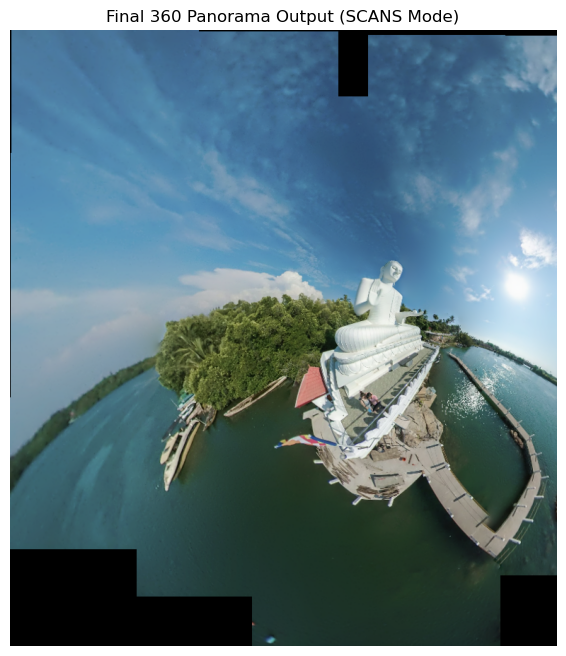

Saved: output_360_panorama\final_360_panorama.jpg

Process completed.


In [2]:
import os
from pathlib import Path
from typing import List
import cv2
import numpy as np
import matplotlib.pyplot as plt


# 1. CONFIGURATION

IMAGE_FOLDER = "360_images"   # change this to your folder name
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]

# Output folder
OUTPUT_FOLDER = "output_360_panorama"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Resize large images for stable stitching
MAX_WIDTH = 1200   # reduce if memory issue
MAX_HEIGHT = 800


# 2. HELPER FUNCTIONS

def resize_image_keep_ratio(img, max_width=1200, max_height=800):
    h, w = img.shape[:2]
    scale = min(max_width / w, max_height / h, 1.0)
    new_w = int(w * scale)
    new_h = int(h * scale)
    return cv2.resize(img, (new_w, new_h))

def load_images(folder: str) -> List[np.ndarray]:
    if not os.path.exists(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")
    
    images = []
    file_names = []
    
    for file in sorted(os.listdir(folder)):
        full_path = os.path.join(folder, file)
        if os.path.isfile(full_path) and Path(file).suffix.lower() in IMAGE_EXTENSIONS:
            img = cv2.imread(full_path)
            if img is not None:
                img = resize_image_keep_ratio(img, MAX_WIDTH, MAX_HEIGHT)
                images.append(img)
                file_names.append(file)
                print(f"Loaded: {file} | shape: {img.shape}")
            else:
                print(f"Could not read: {file}")
    
    print(f"\nTotal loaded images: {len(images)}")
    return images

def show_images(images: List[np.ndarray], titles=None, cols=4, figsize=(18, 10)):
    if len(images) == 0:
        print("No images to display.")
        return
    
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if titles and i < len(titles):
            plt.title(titles[i])
        else:
            plt.title(f"Image {i+1}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

def crop_black_borders(img: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    
    if coords is None:
        return img
    
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y+h, x:x+w]

def save_image(img: np.ndarray, filename: str):
    save_path = os.path.join(OUTPUT_FOLDER, filename)
    cv2.imwrite(save_path, img)
    print(f"Saved: {save_path}")

    
# 3. FEATURE MATCH VISUALIZATION

def detect_and_match_features(img1, img2):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(nfeatures=4000)

    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    if des1 is None or des2 is None:
        return kp1, des1, kp2, des2, []

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for pair in matches:
        if len(pair) == 2:
            m, n = pair
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

    return kp1, des1, kp2, des2, good_matches

def draw_matches(img1, kp1, img2, kp2, matches, max_matches=60):
    vis = cv2.drawMatches(
        img1, kp1, img2, kp2,
        matches[:max_matches], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    plt.figure(figsize=(18, 8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Top {min(len(matches), max_matches)} Matches")
    plt.axis("off")
    plt.show()


# 4. OPENCV STITCHER FOR 6–8 IMAGES

def stitch_with_opencv(images: List[np.ndarray], mode=cv2.Stitcher_PANORAMA):
    stitcher = cv2.Stitcher_create(mode)
    status, pano = stitcher.stitch(images)
    return status, pano


# 5. LOAD YOUR IMAGES

print("Working directory:", os.getcwd())
print("Using image folder:", IMAGE_FOLDER)
print("Files in folder:", os.listdir(IMAGE_FOLDER))

images = load_images(IMAGE_FOLDER)

if len(images) < 2:
    raise ValueError("Need at least 2 images to stitch")

show_images(
    images,
    titles=[f"Input {i+1}" for i in range(len(images))],
    cols=4,
    figsize=(18, 10)
)


# 6. OPTIONAL: CHECK MATCHING BETWEEN FIRST TWO IMAGES

print("\nChecking feature matching between first two images...")
kp1, des1, kp2, des2, good = detect_and_match_features(images[0], images[1])
print("Good matches:", len(good))

if len(good) > 0:
    draw_matches(images[0], kp1, images[1], kp2, good)


# 7. STITCH IN PANORAMA MODE

print("\nRunning OpenCV Stitcher in PANORAMA mode...")
status_pano, pano = stitch_with_opencv(images, mode=cv2.Stitcher_PANORAMA)

pano_ok = False
if status_pano == cv2.Stitcher_OK:
    pano_ok = True
    pano = crop_black_borders(pano)

    plt.figure(figsize=(20, 8))
    plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
    plt.title("360 Panorama Result - PANORAMA Mode")
    plt.axis("off")
    plt.show()

    save_image(pano, "panorama_mode_result.jpg")
else:
    print("PANORAMA mode failed. Status code:", status_pano)


# 8. STITCH IN SCANS MODE

print("\nRunning OpenCV Stitcher in SCANS mode...")
status_scans, pano_scans = stitch_with_opencv(images, mode=cv2.Stitcher_SCANS)

scans_ok = False
if status_scans == cv2.Stitcher_OK:
    scans_ok = True
    pano_scans = crop_black_borders(pano_scans)

    plt.figure(figsize=(20, 8))
    plt.imshow(cv2.cvtColor(pano_scans, cv2.COLOR_BGR2RGB))
    plt.title("360 Panorama Result - SCANS Mode")
    plt.axis("off")
    plt.show()

    save_image(pano_scans, "scans_mode_result.jpg")
else:
    print("SCANS mode failed. Status code:", status_scans)


# 9. COMPARE BOTH RESULTS

results = []
titles = []

if pano_ok:
    results.append(pano)
    titles.append("PANORAMA Mode")

if scans_ok:
    results.append(pano_scans)
    titles.append("SCANS Mode")

if len(results) > 0:
    plt.figure(figsize=(10 * len(results), 7))
    for i, img in enumerate(results):
        plt.subplot(1, len(results), i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


# 10. FINAL BEST OUTPUT

if pano_ok:
    final_output = pano
    final_name = "PANORAMA Mode"
elif scans_ok:
    final_output = pano_scans
    final_name = "SCANS Mode"
else:
    final_output = None
    final_name = None

if final_output is not None:
    print(f"\nBest final output selected: {final_name}")
    
    plt.figure(figsize=(22, 8))
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.title(f"Final 360 Panorama Output ({final_name})")
    plt.axis("off")
    plt.show()

    save_image(final_output, "final_360_panorama.jpg")
else:
    print("\nStitching failed in both PANORAMA and SCANS mode.")
    print("Possible reasons:")
    print("- not enough overlap")
    print("- images not in correct sequence")
    print("- too much camera movement")
    print("- large exposure change")
    print("- moving objects in scene")

print("\nProcess completed.")